# Clusterização de Mercados Consumidores

Objetivo:

Identificar grupos de municípios com características econômicas e demográficas semelhantes utilizando técnicas de aprendizado não supervisionado.

Variáveis utilizadas:

- PIB Municipal
- PIB per capita
- População Residente
- Área Territorial
- Densidade Demográfica

Aplicação de negócio:

Segmentação de mercados para estratégias de expansão comercial, definição de territórios de vendas, inteligência de mercado e direcionamento de campanhas.

In [2]:
# Carregamento da Base Analítica
import pandas as pd

df_municipios = pd.read_csv(
    "dados/processados/base_municipios_enriquecida.csv",
    encoding="utf-8-sig"
)

print("Dimensões:")
print(df_municipios.shape)

display(df_municipios.head())

Dimensões:
(5570, 16)


,NC,NN,MC,MN,pib_municipal,codigo_municipio,municipio,D2C,D2N,D3C,ano,populacao_residente,pib_per_capita,faixa_pib_per_capita,area_km2,densidade_demografica
0,6,Município,40,Mil Reais,919520,1100015,Alta Floresta D'Oeste - RO,37,Produto Interno Bruto a preços correntes,2022,2022,21494,42.780311,Potencial Alto,7067.127,3.04
1,6,Município,40,Mil Reais,3809355,1100023,Ariquemes - RO,37,Produto Interno Bruto a preços correntes,2022,2022,96833,39.339430,Potencial Alto,4426.571,21.88
2,6,Município,40,Mil Reais,289783,1100031,Cabixi - RO,37,Produto Interno Bruto a preços correntes,2022,2022,5351,54.154924,Potencial Muito Alto,1314.352,4.07
3,6,Município,40,Mil Reais,3195489,1100049,Cacoal - RO,37,Produto Interno Bruto a preços correntes,2022,2022,86887,36.777527,Potencial Alto,3793.000,22.91
4,6,Município,40,Mil Reais,903099,1100056,Cerejeiras - RO,37,Produto Interno Bruto a preços correntes,2022,2022,15890,56.834424,Potencial Muito Alto,2783.300,5.71


In [3]:
# Seleção das Variáveis da Clusterização
variaveis_cluster = [
    "pib_municipal",
    "pib_per_capita",
    "populacao_residente",
    "area_km2",
    "densidade_demografica"
]

X = df_municipios[variaveis_cluster]

print(X.shape)
X.head()

(5570, 5)


,pib_municipal,pib_per_capita,populacao_residente,area_km2,densidade_demografica
0,919520,42.780311,21494,7067.127,3.04
1,3809355,39.339430,96833,4426.571,21.88
2,289783,54.154924,5351,1314.352,4.07
3,3195489,36.777527,86887,3793.000,22.91
4,903099,56.834424,15890,2783.300,5.71


In [4]:
# Padronização 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Dimensões após padronização:")
print(X_scaled.shape)

Dimensões após padronização:
(5570, 5)


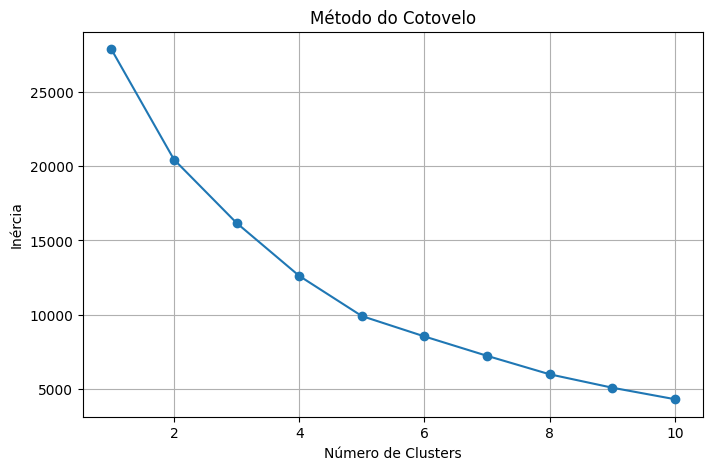

In [5]:
# Método do Cotovelo (Elbow Method)
# Objetivo: Identificar a quantidade ideal de clusters para segmentar os municípios brasileiros.
# Aplicação de Negócio: A definição adequada da quantidade de clusters evita segmentações excessivamente
# simples ou excessivamente complexas, permitindo identificar grupos de municípios com características 
# econômicas e demográficas realmente distintas.

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []

for k in range(1, 11):
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inercia.append(modelo.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inercia,
    marker="o"
)

plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inércia")

plt.grid(True)

plt.show()

In [6]:
#Avaliação da Qualidade dos Clusters (Silhouette Score)
# Objetivo: Validar estatisticamente a qualidade da segmentação proposta pelo algoritmo de clusterização.
# Como funciona: mede simultaneamente A proximidade dos elementos dentro do mesmo cluster e
# a distância entre elementos pertencentes a clusters diferentes.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados = []

for k in range(2, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = modelo.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        clusters
    )

    resultados.append(
        [k, score]
    )

df_silhouette = pd.DataFrame(
    resultados,
    columns=[
        "clusters",
        "silhouette"
    ]
)

display(df_silhouette)

,clusters,silhouette
0,2,0.977639
1,3,0.885064
2,4,0.888300
3,5,0.775036
4,6,0.797464
5,7,0.787392
6,8,0.538945
7,9,0.556744
8,10,0.533365


## Validação da Quantidade de Clusters

A definição da quantidade de clusters foi realizada utilizando duas abordagens complementares:

- Método do Cotovelo (Elbow Method)
- Silhouette Score

Embora o modelo com 2 clusters tenha apresentado o maior índice de separação estatística, essa configuração geraria uma segmentação excessivamente simplificada para aplicação em Inteligência de Mercado.

O modelo com 4 clusters apresentou elevado desempenho estatístico (Silhouette = 0,888) e maior capacidade de diferenciação entre perfis econômicos e demográficos dos municípios brasileiros.

Dessa forma, optou-se pela utilização de 4 clusters por oferecer melhor equilíbrio entre qualidade estatística e interpretabilidade de negócio.

In [7]:
# — Criação dos Clusters com K-Means ──────────────────────────────
# COMO funciona: aplica o algoritmo K-Means sobre as variáveis padronizadas.
# ONDE é usado: etapa principal de segmentação dos municípios.
# POR QUE esta escolha: identificar grupos naturais de municípios com
# características econômicas e demográficas semelhantes.
# QUANDO rodar: após definir a quantidade ideal de clusters utilizando
# Método do Cotovelo e Silhouette Score.
# O QUE produz: nova coluna denominada "cluster" indicando o grupo
# atribuído a cada município.

from sklearn.cluster import KMeans

modelo_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_municipios["cluster"] = modelo_kmeans.fit_predict(
    X_scaled
)

print("Quantidade de municípios por cluster:")

display(
    df_municipios["cluster"]
    .value_counts()
    .sort_index()
)

Quantidade de municípios por cluster:


cluster
0      29
1    5482
2       2
3      57
Name: count, dtype: int64

In [8]:
# — Identificação dos Municípios por Cluster ──────────────────────
# COMO funciona: exibe os municípios pertencentes a cada cluster criado.
# ONDE é usado: interpretação dos resultados da clusterização.
# POR QUE esta escolha: entender quais características diferenciam os grupos.
# QUANDO rodar: após a criação da coluna cluster.
# O QUE produz: relação dos municípios classificados em cada grupo.

for cluster in sorted(df_municipios["cluster"].unique()):

    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}")
    print(f"{'='*60}")

    display(
        df_municipios[
            df_municipios["cluster"] == cluster
        ][
            [
                "municipio",
                "pib_municipal",
                "populacao_residente",
                "pib_per_capita"
            ]
        ]
        .sort_values(
            by="pib_municipal",
            ascending=False
        )
        .head(20)
    )


CLUSTER 0


,municipio,pib_municipal,populacao_residente,pib_per_capita
16,Porto Velho - RO,22537533,460434,48.948455
93,Coari - AM,4861891,70616,68.849708
5128,Corumbá - MS,3858947,96268,40.085459
208,Itaituba - PA,3757070,123314,30.467506
158,Altamira - PA,3457957,126279,27.383468
270,São Félix do Xingu - PA,2020085,65418,30.879651
234,Oriximiná - PA,1802512,68294,26.393417
230,Novo Progresso - PA,1280247,33638,38.059546
99,Humaitá - AM,960741,57473,16.716389
147,Rorainópolis - RR,828529,32647,25.378411



CLUSTER 1


,municipio,pib_municipal,populacao_residente,pib_per_capita
3560,Jundiaí - SP,63835907,443221,144.027262
3824,São José dos Campos - SP,56653327,697054,81.275378
4436,Itajaí - SC,50816696,264054,192.448120
3191,Campos dos Goytacazes - RJ,49942074,483540,103.284266
3067,Uberlândia - MG,47790807,713224,67.006729
2315,Betim - MG,47777094,411846,116.007182
3754,Ribeirão Preto - SP,47434521,698642,67.895318
4447,Joinville - SC,45511051,616317,73.843576
3700,Piracicaba - SP,42063297,423323,99.364544
5122,Campo Grande - MS,40478598,898100,45.071371



CLUSTER 2


,municipio,pib_municipal,populacao_residente,pib_per_capita
3829,São Paulo - SP,945946483,11451999,82.600992
3242,Rio de Janeiro - RJ,380381515,6211223,61.241001



CLUSTER 3


,municipio,pib_municipal,populacao_residente,pib_per_capita
5569,Brasília - DF,328789563,2817381,116.700426
3215,Maricá - RJ,158394291,197277,802.902979
2309,Belo Horizonte - MG,115381698,2315560,49.828853
111,Manaus - AM,113465435,2063689,54.981848
3654,Osasco - SP,112145798,728615,153.916400
4005,Curitiba - PR,111760270,1773718,63.009041
4931,Porto Alegre - RS,90214952,1332845,67.686004
3222,Niterói - RJ,88716289,481749,184.154589
3479,Guarulhos - SP,86373710,1291771,66.864568
949,Fortaleza - CE,81362333,2428708,33.500253


## Insight de Negócio — Primeira Clusterização

A primeira execução do algoritmo K-Means revelou forte concentração econômica entre os municípios brasileiros.

São Paulo e Rio de Janeiro foram isolados em um cluster próprio, indicando que suas características econômicas e demográficas são significativamente diferentes do restante do país.

O resultado sugere que variáveis como PIB Municipal e População apresentam elevada assimetria, fazendo com que grandes centros econômicos exerçam influência desproporcional sobre a segmentação.

Essa descoberta reforça uma característica estrutural da economia brasileira: poucos municípios concentram parcela relevante da atividade econômica nacional.

Como próxima etapa, será aplicada transformação logarítmica nas variáveis de maior amplitude para reduzir o impacto dos extremos e permitir a identificação de perfis de mercado mais comparáveis entre si.

In [9]:
# — Transformação Logarítmica das Variáveis ──────────────────────
# COMO funciona: aplica logaritmo nas variáveis com grande amplitude.
# ONDE é usado: preparação para nova clusterização.
# POR QUE esta escolha: reduzir a influência excessiva de municípios muito acima
# da média, como São Paulo e Rio de Janeiro.
# QUANDO rodar: após avaliar os primeiros clusters.
# O QUE produz: novas variáveis transformadas para utilização no K-Means.

import numpy as np

X_log = pd.DataFrame()

X_log["pib_municipal"] = np.log1p(
    df_municipios["pib_municipal"]
)

X_log["pib_per_capita"] = np.log1p(
    df_municipios["pib_per_capita"]
)

X_log["populacao_residente"] = np.log1p(
    df_municipios["populacao_residente"]
)

X_log["area_km2"] = np.log1p(
    df_municipios["area_km2"]
)

X_log["densidade_demografica"] = np.log1p(
    df_municipios["densidade_demografica"]
)

print("Dimensões:")
print(X_log.shape)

display(X_log.head())

Dimensões:
(5570, 5)


,pib_municipal,pib_per_capita,populacao_residente,area_km2,densidade_demografica
0,13.731608,3.779184,9.975576,8.863351,1.396245
1,15.152971,3.697329,11.480753,8.395606,3.130263
2,12.576891,4.010146,8.585226,7.181860,1.623341
3,14.977251,3.631714,11.372375,8.241176,3.174297
4,13.713589,4.057584,9.673508,7.931752,1.903599
